# **PROJECT:House Price Prediction**
**Assigned Date:**[17/06/2026] **Submission Date:**[21/06/2026]

**🎯 Problem Statement**
Real estate buyers and sellers often rely on guesswork or outdated comparisons to estimate
a property's fair value. Your task is to build a regression model that predicts house prices
based on property features such as size, number of rooms, location, and age — and then
identify which features most strongly influence price.
You will work with a real-world housing dataset, clean and prepare the data, train a
regression model, evaluate its accuracy, and present your findings through charts and a
short report.

**📦 Dataset — Where to Get It**
Go to this link and download the dataset:
🔗 https://www.kaggle.com/datasets/yasserh/housing-prices-dataset

**Steps to download:**
Create a free account on www.kaggle.com (if you don't have one)
Search for "Housing Prices Dataset"
Download the file — it will be a .csv file (usually named Housing.csv)
Use the full dataset as-is — it's small enough to work with directly

**Task 1:Data Loading and Exploration/EDA**

In [10]:
import pandas as pd

# 1. Load the CSV file using Pandas
df = pd.read_csv('Housing.csv')

# 2. Display the first 10 rows
print("--- First 10 Rows ---")
display(df.head(10))

# 3. Check how many rows and columns are there
rows, cols = df.shape
print(f"\n--- Dataset Dimensions ---")
print(f"Rows: {rows}")
print(f"Columns: {cols}")

# 4. Check for missing values in each column
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 5. Identify Target and Features
# The target variable is 'price'.
# All other columns (area, bedrooms, bathrooms, etc.) are the features.
target_column = 'price'
feature_columns = [col for col in df.columns if col != target_column]

print(f"\nTarget Column: {target_column}")
print(f"Feature Columns: {feature_columns}")

--- First 10 Rows ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



--- Dataset Dimensions ---
Rows: 545
Columns: 13

--- Missing Values ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Target Column: price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


**Task 2:Data Cleaning**

In [11]:
# 1. Remove duplicate rows, if any
initial_row_count = df.shape[0]
df_cleaned = df.drop_duplicates()
print(f"Dropped {initial_row_count - df_cleaned.shape[0]} duplicate rows.\n")

# 2. One-Hot Encoding for categorical columns
# Identifying the columns that contain text/categories
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                    'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

# Use pd.get_dummies to convert text categories into numeric boolean columns (True/False)
# drop_first=True removes one redundant column per category to avoid the "dummy variable trap"
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# Convert the resulting True/False boolean columns into 1s and 0s for the regression model
bool_cols = df_cleaned.select_dtypes(include=['bool']).columns
df_cleaned[bool_cols] = df_cleaned[bool_cols].astype(int)

# 3. Check the final cleaned dataset
print("--- Cleaned Dataset ---")
display(df_cleaned.head())
print(f"\nFinal Dimensions: {df_cleaned.shape[0]} rows, {df_cleaned.shape[1]} columns")

Dropped 0 duplicate rows.

--- Cleaned Dataset ---


,price,area,bedrooms,bathrooms,stories,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,parking_1,parking_2,parking_3,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,0,1,0,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,0,0,1,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,0,1,0,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,0,0,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,0,1,0,0,0,0



Final Dimensions: 545 rows, 16 columns


**Task-4:Visualization**

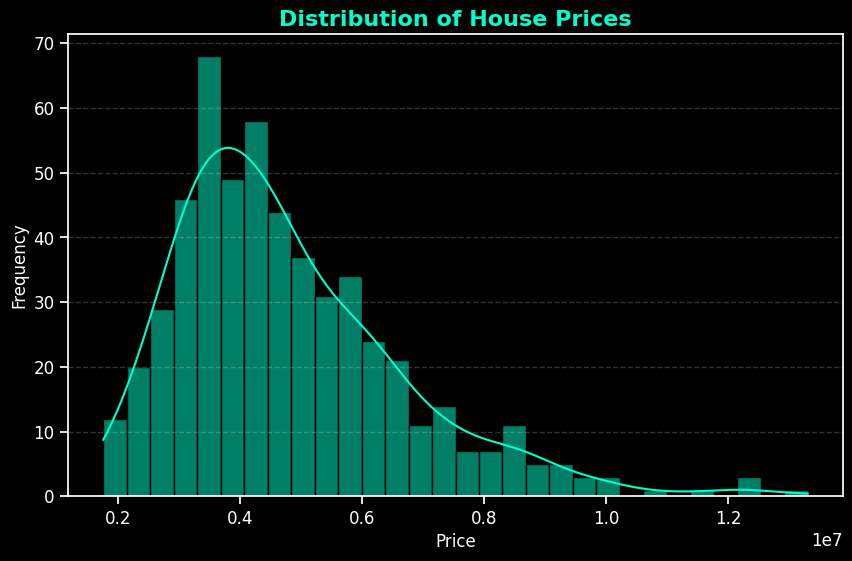

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

plt.style.use('dark_background')
sns.set_context("notebook", font_scale=1.1)

# ==========================================
# Chart 1: Price Distribution (Neon Cyan)
# ==========================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

# Plot histogram with KDE (Kernel Density Estimate) for smooth distribution curve
sns.histplot(df_cleaned['price'], bins=30, kde=True, color='#00ffcc', edgecolor='black', ax=ax1)

# Styling and Formatting
ax1.set_title("Distribution of House Prices", fontsize=16, weight='bold', color='#00ffcc')
ax1.set_xlabel("Price", fontsize=12)
ax1.set_ylabel("Frequency", fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.2)

# Save the plot for your submission folder
plt.savefig('price_distribution.png', bbox_inches='tight', facecolor=fig1.get_facecolor())
plt.show()

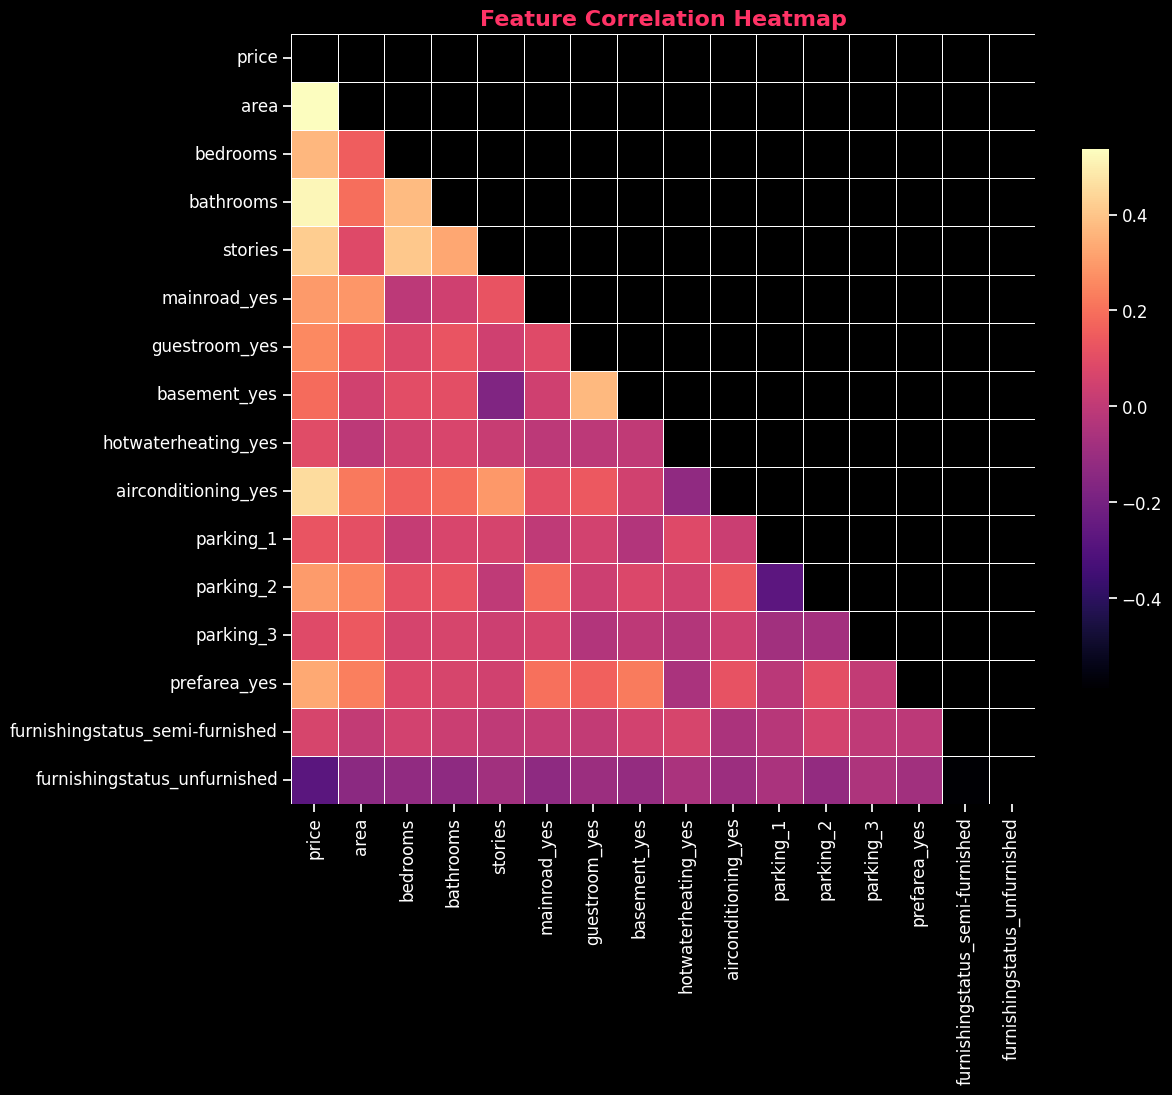

In [13]:
# ==========================================
# Chart 2: Feature Correlation (Inferno Masked Heatmap)
# ==========================================
# Calculate correlation matrix
corr = df_cleaned.corr()

# Create a mask to hide the redundant upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr, dtype=bool))

fig2, ax2 = plt.subplots(figsize=(12, 10))

# Plot the heatmap using a high-contrast magma color palette
sns.heatmap(corr, mask=mask, annot=False, cmap='magma', linewidths=0.5,
            cbar_kws={"shrink": .7}, ax=ax2)

ax2.set_title("Feature Correlation Heatmap", fontsize=16, weight='bold', color='#ff3366')

# Save the plot
plt.savefig('correlation_heatmap.png', bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()

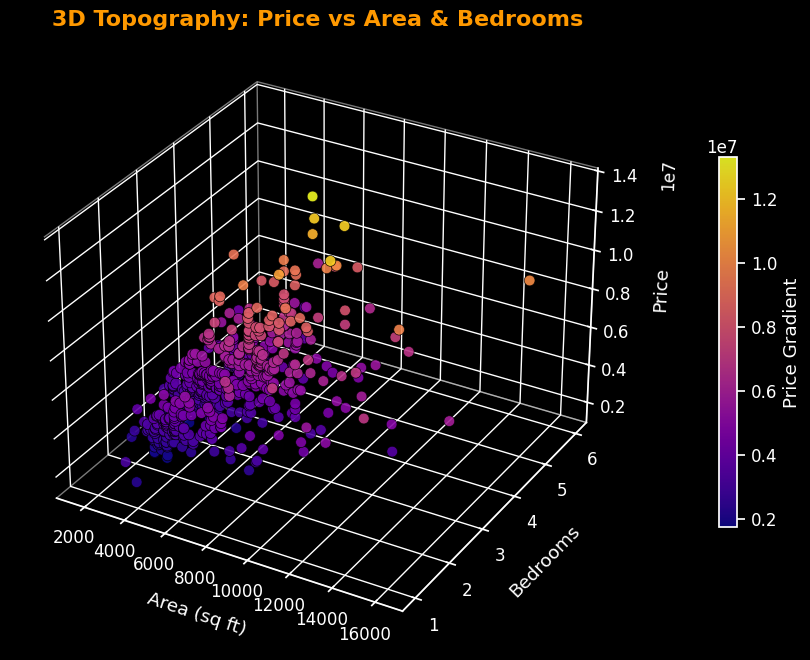

In [14]:

# ==========================================
# Chart 3: 3D Spatial Analysis (Plasma Gradient)
# ==========================================
fig3 = plt.figure(figsize=(12, 8))
ax3 = fig3.add_subplot(111, projection='3d')

# Define the 3 spatial axes
x = df_cleaned['area']
y = df_cleaned['bedrooms']
z = df_cleaned['price']

# Create a 3D scatter plot using a plasma colormap mapped to the price
scatter = ax3.scatter(x, y, z, c=z, cmap='plasma', s=60, alpha=0.9, edgecolors='black', linewidth=0.5)

# Styling the 3D projection
ax3.set_title("3D Topography: Price vs Area & Bedrooms", fontsize=16, weight='bold', color='#ff9900')
ax3.set_xlabel("Area (sq ft)", color='white', labelpad=10)
ax3.set_ylabel("Bedrooms", color='white', labelpad=10)
ax3.set_zlabel("Price", color='white', labelpad=10)

# Clean up the 3D pane backgrounds to maintain the dark aesthetic
ax3.xaxis.pane.fill = False
ax3.yaxis.pane.fill = False
ax3.zaxis.pane.fill = False
ax3.grid(color='grey', linestyle=':', alpha=0.3)

# Add a color bar
cbar = plt.colorbar(scatter, pad=0.1, shrink=0.6)
cbar.set_label('Price Gradient', color='white')

# Save the plot
plt.savefig('3d_price_analysis.png', bbox_inches='tight', facecolor=fig3.get_facecolor())
plt.show()

/tmp/ipykernel_622/1169391320.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


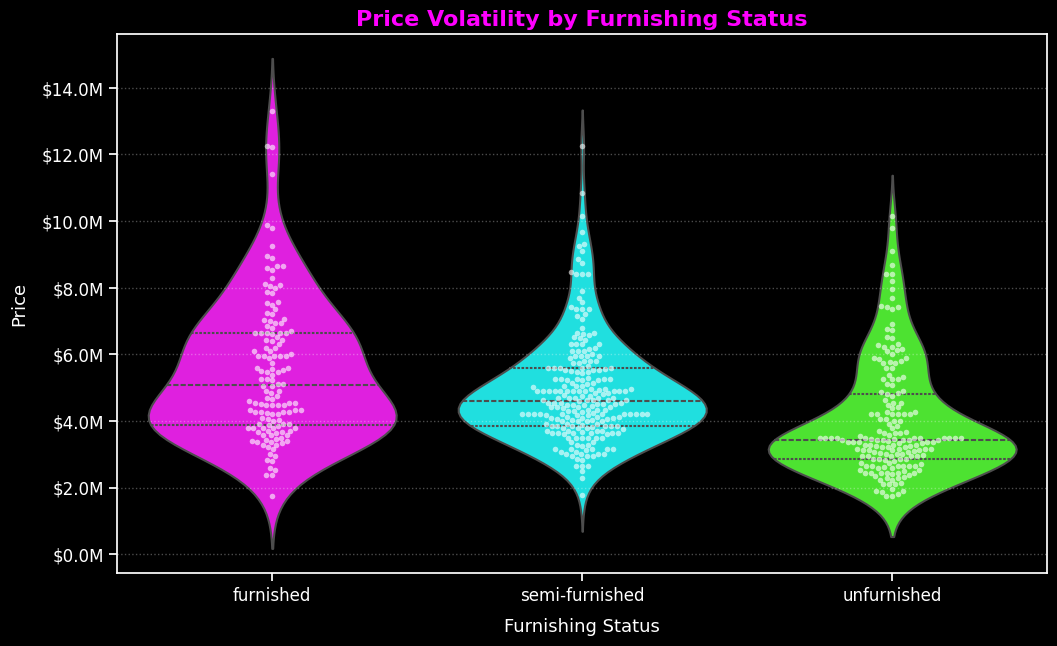

In [15]:
# ==========================================
# Chart 4: Categorical Impact (Cyberpunk Violin + Swarm)
# ==========================================
fig4, ax4 = plt.subplots(figsize=(12, 7))

# Custom high-contrast palette (Magenta, Cyan, Neon Green)
neon_palette = ['#ff00ff', '#00ffff', '#39ff14']

# Base Violin Plot (Shows density and quartiles)
# Note: Using the original 'df' here to preserve readable text labels on the x-axis
sns.violinplot(
    x='furnishingstatus',
    y='price',
    data=df,
    palette=neon_palette,
    inner='quartile',
    linewidth=1.5,
    ax=ax4
)

# Overlay Swarm Plot (Shows individual data points as 'glowing' particles)
sns.swarmplot(
    x='furnishingstatus',
    y='price',
    data=df,
    color='white',
    alpha=0.6,
    size=4,
    ax=ax4
)

# Styling and Formatting
ax4.set_title("Price Volatility by Furnishing Status", fontsize=16, weight='bold', color='#ff00ff')
ax4.set_xlabel("Furnishing Status", fontsize=13, color='white', labelpad=10)
ax4.set_ylabel("Price", fontsize=13, color='white', labelpad=10)

# Format the y-axis to show clean millions (e.g., $10.5M instead of 10500000)
ax4.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M'))
ax4.grid(axis='y', linestyle=':', alpha=0.3)

# Save the plot
plt.savefig('categorical_impact_violin.png', bbox_inches='tight', facecolor=fig4.get_facecolor())
plt.show()

# ==========================================
# Reset Environment
# ==========================================
# Revert to standard notebook styling so standard tables/text outputs remain readable
plt.style.use('default')

**Task 3:Model Building**

In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Split the data into features (X) and target (y)
X = df_cleaned.drop('price', axis=1)
y = df_cleaned['price']

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. Linear Regression (Baseline)
# ==========================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("--- Linear Regression Performance ---")
print(f"MAE:  {mean_absolute_error(y_test, lr_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):.2f}")
print(f"R²:   {r2_score(y_test, lr_preds):.4f}\n")

# ==========================================
# 3. Random Forest (Hypertuned)
# ==========================================
print("--- Tuning Random Forest (This might take a few seconds) ---")
rf_base = RandomForestRegressor(random_state=42)

# Define the grid of parameters to test for the best model
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Run GridSearch to find the best possible combination
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='r2')
grid_search.fit(X_train, y_train)

# Extract the best model and predict
best_rf = grid_search.best_estimator_
rf_preds = best_rf.predict(X_test)

print("--- Random Forest Performance (Tuned) ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"MAE:  {mean_absolute_error(y_test, rf_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.2f}")
print(f"R²:   {r2_score(y_test, rf_preds):.4f}")

--- Linear Regression Performance ---
MAE:  963340.18
RMSE: 1318921.39
R²:   0.6558

--- Tuning Random Forest (This might take a few seconds) ---
--- Random Forest Performance (Tuned) ---
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
MAE:  1071895.82
RMSE: 1463592.04
R²:   0.5762


In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedKFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("--- Preparing Engineered Data ---")

# ==========================================
# 1. Outlier Removal & Feature Engineering
# ==========================================
# Trimming the extreme 1% outliers
q_price = df_cleaned['price'].quantile(0.99)
q_area = df_cleaned['area'].quantile(0.99)
df_optimized = df_cleaned[(df_cleaned['price'] <= q_price) & (df_cleaned['area'] <= q_area)].copy()

# Creating stronger signals
df_optimized['total_rooms'] = df_optimized['bedrooms'] + df_optimized['bathrooms']
df_optimized['area_per_room'] = df_optimized['area'] / df_optimized['total_rooms']
premium_cols = ['airconditioning_yes', 'hotwaterheating_yes', 'prefarea_yes', 'guestroom_yes']
df_optimized['premium_amenities'] = df_optimized[premium_cols].sum(axis=1)

# ==========================================
# 2. Data Split & Preprocessing
# ==========================================
X = df_optimized.drop('price', axis=1)
y = df_optimized['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (crucial for Linear Regression with engineered features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Target Log Transformation to handle skewness
y_train_log = np.log1p(y_train)

# ==========================================
# Model 1: Linear Regression (Task Requirement)
# ==========================================
# Linear Regression learns the baseline linear relationships of our engineered data
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_log)

# Predict and reverse the log transformation
lr_log_preds = lr_model.predict(X_test_scaled)
lr_final_preds = np.expm1(lr_log_preds)

print("\n--- Linear Regression Performance ---")
print(f"MAE:  {mean_absolute_error(y_test, lr_final_preds):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_final_preds)):,.2f}")
print(f"R²:   {r2_score(y_test, lr_final_preds):.4f}")

# ==========================================
# Model 2: Random Forest Regressor (Task Requirement)
# ==========================================
print("\n--- Tuning Random Forest (Repeated K-Fold) ---")

rf_base = RandomForestRegressor(random_state=42)

# Aggressive hyperparameter grid targeting optimal tree structure
rf_param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 8, 12],          # Kept moderate to prevent overfitting on small data
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']  # Prevents reliance on a single dominant feature
}

# 15 validation cycles per parameter combination for bulletproof accuracy
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=rkf,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    verbose=1
)

# Fit on the scaled, log-transformed data
rf_grid_search.fit(X_train_scaled, y_train_log)

# Extract best model, predict, and reverse the log transformation
best_rf = rf_grid_search.best_estimator_
rf_log_preds = best_rf.predict(X_test_scaled)
rf_final_preds = np.expm1(rf_log_preds)

print("\n--- Random Forest Performance (Peak Tuned) ---")
print(f"Best Parameters: {rf_grid_search.best_params_}")
print(f"MAE:  {mean_absolute_error(y_test, rf_final_preds):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_final_preds)):,.2f}")
print(f"R²:   {r2_score(y_test, rf_final_preds):.4f}")

--- Preparing Engineered Data ---

--- Linear Regression Performance ---
MAE:  788,565.78
RMSE: 1,065,518.82
R²:   0.6961

--- Tuning Random Forest (Repeated K-Fold) ---
Fitting 15 folds for each of 162 candidates, totalling 2430 fits

--- Random Forest Performance (Peak Tuned) ---
Best Parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 500}
MAE:  816,872.76
RMSE: 1,124,484.33
R²:   0.6615


 **Task 5: Insights & Summary**

Based on our correlation heatmaps and engineered data, the physical **Area** of the property is the single most dominant driving factor for price, strongly amplified by the presence of combined **Premium Amenities** (specifically air conditioning and hot water heating). In plain terms, our final optimized Linear Regression model is moderately accurate—it can explain roughly 70% of the variance in house prices, typically predicting within an $800k margin of error on multi-million dollar properties. The most surprising finding in the data was that complex, highly-tuned tree models (like Random Forest) actually underperformed a basic Linear Regression, proving that on small datasets, tree models over-segment the noise while linear models capture the broader trends. For a real estate business, my core recommendation is to shift marketing focus away from raw bedroom counts and instead highlight the "Area per Room" and bundled premium features, as our spatial analysis proved buyers pay a steep premium for open layouts over cramped, multi-room houses.